# SE3 Electricity Price Forecast — ML Notebook

This notebook builds a day-ahead electricity price forecasting model for the SE3 bidding area (Sweden).

**What we do, step by step:**
1. Fetch historical SE3 prices from ENTSO-E
2. Fetch weather data from Open-Meteo (free, no key needed)
3. Fetch generation features from ENTSO-E (wind, nuclear, load)
4. Merge all data sources
5. Build features: lags, calendar, weather, generation
6. Train a LightGBM model
7. Evaluate: MAE, MAPE, RMSE
8. Plot forecast vs actual
9. Inspect which features matter most (SHAP)

## 0. Install dependencies
Run this cell once. Restart the kernel after installing.

In [15]:
# Run once, then restart kernel
#!pip install entsoe-py lightgbm shap openmeteo-requests requests-cache retry-requests pandas numpy scikit-learn matplotlib plotly

## 1. Config — put your API key here

In [16]:
# ── Config ──────────────────────────────────────────────────────────────────
import os, getpass
ENTSO_E_API_KEY = os.environ.get("ENTSOE_API_KEY") or getpass.getpass("ENTSO-E API key: ")

SE3_AREA_CODE   = "10Y1001A1001A46L"    # SE3 bidding area
WEATHER_LAT     = 59.33                 # Stockholm (centre of SE3)
WEATHER_LON     = 18.07

# How much history to fetch (more = better model, slower download)
TRAIN_START = "2020-01-01"
TRAIN_END   = "2026-03-31"

# Forecast horizon: predict this many hours ahead
FORECAST_HORIZON = 24   # 24h = day-ahead

## 2. Fetch SE3 prices from ENTSO-E
We pull hourly day-ahead prices for SE3 going back to `TRAIN_START`.

In [17]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=ENTSO_E_API_KEY)

start = pd.Timestamp(TRAIN_START, tz="Europe/Stockholm")
end   = pd.Timestamp(TRAIN_END,   tz="Europe/Stockholm")

print("Fetching prices from ENTSO-E...")
prices = client.query_day_ahead_prices(SE3_AREA_CODE, start=start, end=end)

# Convert to a clean DataFrame
prices = prices.rename("price_eur_mwh").to_frame()
prices.index = prices.index.tz_convert("Europe/Stockholm")
prices.index.name = "timestamp"

print(f"Fetched {len(prices)} hourly price records")
print(f"Price range: {prices.price_eur_mwh.min():.1f} – {prices.price_eur_mwh.max():.1f} EUR/MWh")
prices.head()

Fetching prices from ENTSO-E...


Connection Error, retrying in 10 seconds


Fetched 67770 hourly price records
Price range: -60.0 – 800.0 EUR/MWh


,price_eur_mwh
timestamp,
2020-01-01 00:00:00+01:00,28.78
2020-01-01 01:00:00+01:00,28.45
2020-01-01 02:00:00+01:00,27.90
2020-01-01 03:00:00+01:00,27.52
2020-01-01 04:00:00+01:00,27.54


## 3. Fetch weather data from Open-Meteo
No API key needed. We pull temperature, wind speed, and solar radiation.

In [18]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session  = requests_cache.CachedSession(".weather_cache", expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)
om_client      = openmeteo_requests.Client(session=retry_session)

params = {
    "latitude":   WEATHER_LAT,
    "longitude":  WEATHER_LON,
    "start_date": TRAIN_START,
    "end_date":   TRAIN_END,
    "hourly": [
        "temperature_2m",
        "windspeed_10m",
        "windspeed_100m",    # hub height — better wind farm proxy
        "direct_radiation",
        "cloudcover",        # solar suppression signal
    ],
    "timezone": "Europe/Stockholm",
}

print("Fetching weather from Open-Meteo...")
response = om_client.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0]
hourly   = response.Hourly()

weather = pd.DataFrame({
    "timestamp":       pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ).tz_convert("Europe/Stockholm"),
    "temperature":     hourly.Variables(0).ValuesAsNumpy(),
    "windspeed_10m":   hourly.Variables(1).ValuesAsNumpy(),
    "windspeed_100m":  hourly.Variables(2).ValuesAsNumpy(),
    "solar_radiation": hourly.Variables(3).ValuesAsNumpy(),
    "cloudcover":      hourly.Variables(4).ValuesAsNumpy(),
}).set_index("timestamp")

print(f"Fetched {len(weather)} hourly weather records")
weather.head()

Fetching weather from Open-Meteo...
Fetched 54768 hourly weather records


,temperature,windspeed_10m,windspeed_100m,solar_radiation,cloudcover
timestamp,,,,,
2019-12-31 23:00:00+01:00,0.15,14.113653,30.619051,0.0,13.0
2020-01-01 00:00:00+01:00,0.20,14.843180,31.616526,0.0,9.0
2020-01-01 01:00:00+01:00,0.65,15.391840,31.093666,0.0,19.0
2020-01-01 02:00:00+01:00,1.15,16.946787,33.449017,0.0,1.0
2020-01-01 03:00:00+01:00,0.75,16.418526,32.846916,0.0,98.0


## 4. Fetch generation features from ENTSO-E

Wind generation, nuclear capacity, and total load — the signals that drive price spikes.
Each fetch is wrapped in try/except so a failed query won't crash the notebook.

In [19]:
import numpy as np

def fetch_resample(fetch_fn, label):
    """Fetch from ENTSO-E, sum columns if multi-column, resample to hourly."""
    try:
        print(f"  Fetching {label}...")
        raw = fetch_fn()
        if isinstance(raw, pd.DataFrame):
            series = raw.sum(axis=1)
        else:
            series = raw
        series = series.tz_convert("Europe/Stockholm")
        series = series.resample("h").mean()
        series.name = label
        print(f"    OK — {len(series)} records")
        return series
    except Exception as e:
        print(f"    WARNING: {label} failed ({e}) — will fill with median later")
        return pd.Series(dtype=float, name=label)

print("Fetching generation data from ENTSO-E...")

def fetch_weather_forecast(lat, lon, hours=48):
    """Fetch weather FORECAST for upcoming hours — use this for live prediction only."""
    import openmeteo_requests, requests_cache
    from retry_requests import retry

    cache_session = requests_cache.CachedSession(".weather_forecast_cache", expire_after=3600)  # 1h cache
    retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
    om_client     = openmeteo_requests.Client(session=retry_session)

    params = {
        "latitude":  lat,
        "longitude": lon,
        "hourly": [
            "temperature_2m", "windspeed_10m", "windspeed_100m",
            "direct_radiation", "cloudcover",
        ],
        "forecast_days": 2,   # today + tomorrow
        "timezone": "Europe/Stockholm",
    }

    response = om_client.weather_api(
        "https://api.open-meteo.com/v1/forecast", params=params  # forecast endpoint, not archive
    )[0]
    hourly = response.Hourly()

    df = pd.DataFrame({
        "timestamp":      pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        ).tz_convert("Europe/Stockholm"),
        "temperature":     hourly.Variables(0).ValuesAsNumpy(),
        "windspeed_10m":   hourly.Variables(1).ValuesAsNumpy(),
        "windspeed_100m":  hourly.Variables(2).ValuesAsNumpy(),
        "solar_radiation": hourly.Variables(3).ValuesAsNumpy(),
        "cloudcover":      hourly.Variables(4).ValuesAsNumpy(),
    }).set_index("timestamp")

    return df

wind_gen = fetch_resample(
    lambda: client.query_wind_and_solar_forecast(
        SE3_AREA_CODE, start=start, end=end)["Wind Onshore"],
    "wind_gen_mw"
)

nuclear = fetch_resample(
    lambda: client.query_installed_generation_capacity(
        SE3_AREA_CODE, start=start, end=end)["Nuclear"],
    "nuclear_cap_mw"
)

load = fetch_resample(
    lambda: client.query_load(SE3_AREA_CODE, start=start, end=end),
    "load_mw"
)

gen = pd.concat([wind_gen, nuclear, load], axis=1)
gen = gen.ffill(limit=3)   # forward-fill short gaps (DST transitions etc.)

print(f"\nGeneration features shape: {gen.shape}")
gen.head()

Fetching generation data from ENTSO-E...
  Fetching wind_gen_mw...
    OK — 54743 records
  Fetching nuclear_cap_mw...
  Fetching load_mw...
    OK — 54743 records

Generation features shape: (54743, 3)


,wind_gen_mw,nuclear_cap_mw,load_mw
2020-01-01 00:00:00+01:00,1505.78,NaN,9518.0
2020-01-01 01:00:00+01:00,1592.88,NaN,9350.0
2020-01-01 02:00:00+01:00,1668.06,NaN,9158.0
2020-01-01 03:00:00+01:00,1757.30,NaN,8980.0
2020-01-01 04:00:00+01:00,1856.33,NaN,8914.0


## 5. Merge all data sources

In [20]:
# Join prices + weather + generation on timestamp
df = prices.join(weather, how="inner").join(gen, how="left")

# Fill any remaining NaNs in generation columns with column median
for col in ["wind_gen_mw", "load_mw", "nuclear_cap_mw"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Ensure DatetimeIndex with timezone (DST-safe)
df.index = pd.to_datetime(df.index)   # convert first, then check tz
if df.index.tz is None:
    df.index = df.index.tz_localize(
        "Europe/Stockholm", ambiguous="infer", nonexistent="shift_forward"
    )

df = df.dropna(subset=["price_eur_mwh", "temperature", "windspeed_10m"])

print(f"Combined dataset: {len(df)} hours ({df.index.min().date()} → {df.index.max().date()})")
print(f"Columns: {list(df.columns)}")
df.head()

Combined dataset: 54738 hours (2020-01-01 → 2026-03-31)
Columns: ['price_eur_mwh', 'temperature', 'windspeed_10m', 'windspeed_100m', 'solar_radiation', 'cloudcover', 'wind_gen_mw', 'nuclear_cap_mw', 'load_mw']


,price_eur_mwh,temperature,windspeed_10m,windspeed_100m,solar_radiation,cloudcover,wind_gen_mw,nuclear_cap_mw,load_mw
timestamp,,,,,,,,,
2020-01-01 00:00:00+01:00,28.78,0.20,14.843180,31.616526,0.0,9.0,1505.78,NaN,9518.0
2020-01-01 01:00:00+01:00,28.45,0.65,15.391840,31.093666,0.0,19.0,1592.88,NaN,9350.0
2020-01-01 02:00:00+01:00,27.90,1.15,16.946787,33.449017,0.0,1.0,1668.06,NaN,9158.0
2020-01-01 03:00:00+01:00,27.52,0.75,16.418526,32.846916,0.0,98.0,1757.30,NaN,8980.0
2020-01-01 04:00:00+01:00,27.54,0.90,17.727943,34.569374,0.0,55.0,1856.33,NaN,8914.0


## 6. Feature engineering

Key features:
- **Lag features** — past prices (24h, 48h, 168h) and rolling stats
- **Cyclical calendar** — sin/cos encodings so midnight is adjacent to 23:00
- **Interaction features** — wind × time-of-day, temperature × season, lag × hour
- **Generation features** — wind gen, load, wind penetration ratio

In [21]:
import numpy as np
import holidays

se_holidays = holidays.Sweden()

def build_features(df):
    X = df.copy()

    # Ensure DatetimeIndex with timezone
    X.index = pd.to_datetime(X.index)
    if X.index.tz is None:
        X.index = X.index.tz_localize(
            "Europe/Stockholm", ambiguous="infer", nonexistent="shift_forward"
        )

    # ── Lag features ────────────────────────────────────────────────────────
    X["price_lag_24h"]        = X["price_eur_mwh"].shift(24)
    X["price_lag_48h"]        = X["price_eur_mwh"].shift(48)
    X["price_lag_168h"]       = X["price_eur_mwh"].shift(168)
    X["price_roll_168h_mean"] = X["price_eur_mwh"].shift(24).rolling(168).mean()
    X["price_roll_168h_std"]  = X["price_eur_mwh"].shift(24).rolling(168).std()
    X["price_roll_720h_mean"] = X["price_eur_mwh"].shift(24).rolling(720).mean()  # 30d regime anchor

    # ── Calendar — cyclical encodings ────────────────────────────────────────
    X["hour"]       = X.index.hour
    X["dayofweek"]  = X.index.dayofweek
    X["month"]      = X.index.month
    # Cyclical: midnight adjacent to 23:00, Jan adjacent to Dec, Mon adjacent to Sun
    X["hour_sin"]   = np.sin(2 * np.pi * X["hour"]      / 24)
    X["hour_cos"]   = np.cos(2 * np.pi * X["hour"]      / 24)
    X["month_sin"]  = np.sin(2 * np.pi * X["month"]     / 12)
    X["month_cos"]  = np.cos(2 * np.pi * X["month"]     / 12)
    X["dow_sin"]    = np.sin(2 * np.pi * X["dayofweek"] / 7)
    X["dow_cos"]    = np.cos(2 * np.pi * X["dayofweek"] / 7)

    # ── Fourier harmonics ────────────────────────────────────────────────────
    # k=1: fundamental daily/weekly shape
    # k=2: DOUBLE-PEAK structure (morning + evening peaks, midnight + midday troughs)
    # k=3: finer detail (pre-dawn uptick, sharper peak transitions)
    hour_of_week = X["dayofweek"] * 24 + X["hour"]
    hour_of_year = (X.index.dayofyear - 1) * 24 + X["hour"]

    for k in [1, 2, 3]:
        X[f"daily_sin_k{k}"]  = np.sin(2 * np.pi * k * X["hour"]    / 24)
        X[f"daily_cos_k{k}"]  = np.cos(2 * np.pi * k * X["hour"]    / 24)
        X[f"weekly_sin_k{k}"] = np.sin(2 * np.pi * k * hour_of_week / 168)
        X[f"weekly_cos_k{k}"] = np.cos(2 * np.pi * k * hour_of_week / 168)

    for k in [1, 2]:
        X[f"annual_sin_k{k}"] = np.sin(2 * np.pi * k * hour_of_year / 8760)
        X[f"annual_cos_k{k}"] = np.cos(2 * np.pi * k * hour_of_year / 8760)


    X["season"]     = X["month"].map(
        {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
    )
    X["is_weekend"] = (X.index.dayofweek >= 5).astype(int)
    X["is_holiday"] = X.index.normalize().map(lambda d: int(d in se_holidays))
    X["is_peak"]    = (X["hour"].isin(range(7, 10)) | X["hour"].isin(range(17, 21))).astype(int)
    X["is_night"]   = X["hour"].isin([23, 0, 1, 2, 3, 4, 5]).astype(int)

    # ── Weather features ─────────────────────────────────────────────────────
    wind_col = "windspeed_100m" if "windspeed_100m" in X.columns else "windspeed_10m"
    w = X[wind_col]

    X["heating_degree"]  = (15 - X["temperature"]).clip(lower=0)   # non-linear heating load

    # ── Interaction features ─────────────────────────────────────────────────
    # Wind × time-of-day: high wind at night/weekend = price crash
    X["wind_x_night"]    = w * X["is_night"]
    X["wind_x_peak"]     = w * X["is_peak"]
    X["wind_x_weekend"]  = w * X["is_weekend"]
    # Wind × season: winter wind matters more (high baseline demand)
    X["wind_x_winter"]   = w * (X["season"] == 1).astype(int)
    X["wind_x_summer"]   = w * (X["season"] == 3).astype(int)
    # Wind² — very high wind has outsized price impact vs moderate wind
    X["wind_squared"]    = w ** 2

    # Temperature interactions
    X["temp_x_night"]    = X["temperature"] * X["is_night"]   # cold nights = high heating load
    X["temp_x_peak"]     = X["temperature"] * X["is_peak"]    # cold peak = worst grid stress
    X["temp_x_winter"]   = X["temperature"] * (X["season"] == 1).astype(int)

    # Cloudcover × solar: partial cloud vs full overcast
    if "cloudcover" in X.columns and "solar_radiation" in X.columns:
        X["cloud_x_solar"] = X["cloudcover"] * X["solar_radiation"]

    # Lag × hour: yesterday midnight anchors midnight, yesterday peak anchors peak
    X["lag24_x_hour_sin"]  = X["price_lag_24h"] * X["hour_sin"]
    X["lag24_x_hour_cos"]  = X["price_lag_24h"] * X["hour_cos"]

    X["price_same_hour_3d_mean"] = (
    X["price_eur_mwh"].shift(24) +
    X["price_eur_mwh"].shift(48) +
    X["price_eur_mwh"].shift(72)
    ) / 3

    X["price_lag24_vs_3d_mean"] = X["price_lag_24h"] - X["price_same_hour_3d_mean"]
    # Regime × volatility: distinguishes high-vol/high-price (2022) from high-vol/low-price (2024)
    X["regime_x_vol"]      = X["price_roll_720h_mean"] * X["price_roll_168h_std"]
    # Average price at the same hour over the last 7 days
    # Captures "midnight typically costs X" rather than "yesterday midnight cost Y"
    X["price_same_hour_7d_mean"] = (
        X["price_eur_mwh"].shift(24)  +
        X["price_eur_mwh"].shift(48)  +
        X["price_eur_mwh"].shift(72)  +
        X["price_eur_mwh"].shift(96)  +
        X["price_eur_mwh"].shift(120) +
        X["price_eur_mwh"].shift(144) +
        X["price_eur_mwh"].shift(168)
        ) / 7
    # 7-day rolling mean wind at the same hour — "typical wind for this hour"
    X["wind_7d_mean"] = (
        X["windspeed_100m"].shift(24) +
        X["windspeed_100m"].shift(48) +
        X["windspeed_100m"].shift(72) +
        X["windspeed_100m"].shift(96) +
        X["windspeed_100m"].shift(120) +
        X["windspeed_100m"].shift(144) +
        X["windspeed_100m"].shift(168)
    ) / 7

    # How much windier than usual is tonight?
    # Positive = windier than typical = should be cheaper
    X["wind_surprise"] = X["windspeed_100m"] - X["wind_7d_mean"]

    # Wind surprise × night: extra powerful signal for overnight low prices
    X["wind_surprise_x_night"] = X["wind_surprise"] * X["is_night"]

    # Direct override: high wind tonight vs typical price anchor
    # When this is large and positive, price should be well below the 7d mean
    X["wind_vs_price_anchor"] = X["wind_surprise"] * X["price_same_hour_7d_mean"]
    # How unusual was yesterday vs the typical same-hour price?
    # Positive = yesterday was expensive, negative = yesterday was cheap
    X["price_lag24_vs_hour_mean"] = X["price_lag_24h"] - X["price_same_hour_7d_mean"]
    # ── Generation features ──────────────────────────────────────────────────
    if "wind_gen_mw" in X.columns:
        X["wind_gen_lag24"]    = X["wind_gen_mw"].shift(24)
        X["load_lag24"]        = X["load_mw"].shift(24)
        X["wind_load_ratio"]   = X["wind_gen_lag24"] / (X["load_lag24"] + 1)
        # Wind gen × night/weekend: surplus when demand is lowest = near-zero prices
        X["wind_gen_x_night"]  = X["wind_gen_lag24"] * X["is_night"]
        X["wind_gen_x_weekend"]= X["wind_gen_lag24"] * X["is_weekend"]
        # Load residual: how much load is NOT covered by wind
        X["load_residual"]     = (X["load_lag24"] - X["wind_gen_lag24"]).clip(lower=0)

    if "nuclear_cap_mw" in X.columns and X["nuclear_cap_mw"].notna().any():
        X["nuclear_cap_lag24"] = X["nuclear_cap_mw"].shift(24)
        X["nuclear_shortfall"] = (
            X["nuclear_cap_lag24"].shift(1).rolling(168).max() - X["nuclear_cap_lag24"]
        )
        X["nuclear_x_peak"]    = X["nuclear_cap_lag24"] * X["is_peak"]
    else:
        print("  nuclear_cap_mw unavailable — skipping nuclear features")

    return X

# Call ONCE only
df = build_features(df)

# Drop all-NaN columns (failed nuclear fetch etc.)
df = df.dropna(axis=1, how="all")

# Drop rows where core rolling features are NaN (first ~720 rows)
df = df.dropna(subset=["price_roll_720h_mean", "price_roll_168h_mean", "price_lag_168h"])

print(f"Features built. Dataset size: {len(df)} rows")
print(f"Total columns: {len(df.columns)}")

  nuclear_cap_mw unavailable — skipping nuclear features
Features built. Dataset size: 53995 rows
Total columns: 72


## 7. Train / test split
We keep the last 90 days as a test set. Everything before is training data.

In [22]:
FEATURE_COLS = [
    "price_same_hour_7d_mean",   # primary anchor — stable same-hour average
    "price_lag24_vs_hour_mean",  # deviation: was yesterday unusual?
    # ── Price lags ──────────────────────────────────────────────────────────
     "price_lag_48h", "price_lag_168h",
    "price_roll_168h_mean", "price_roll_168h_std",
    "price_roll_720h_mean",

    # ── Calendar — cyclical encodings replace raw integers ──────────────────
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "dow_sin", "dow_cos",
    "season", "is_night", "is_peak", "is_weekend", "is_holiday",

    # ── Weather ─────────────────────────────────────────────────────────────
    "temperature", "cloudcover", "heating_degree","wind_7d_mean", "wind_surprise", "wind_surprise_x_night", "wind_vs_price_anchor"
]

# Wind — prefer 100m
wind_col = "windspeed_100m" if "windspeed_100m" in df.columns else "windspeed_10m"
FEATURE_COLS += [
    wind_col, "wind_squared",
    "wind_x_night", "wind_x_peak", "wind_x_weekend",
    "wind_x_winter", "wind_x_summer",
]

# Solar
if "solar_radiation" in df.columns:
    FEATURE_COLS.append("solar_radiation")
if "cloud_x_solar" in df.columns:
    FEATURE_COLS.append("cloud_x_solar")

# Temperature interactions
FEATURE_COLS += ["temp_x_night", "temp_x_peak", "temp_x_winter"]

# Lag × hour interactions
FEATURE_COLS += ["lag24_x_hour_sin", "lag24_x_hour_cos"]

# Regime × volatility
FEATURE_COLS += ["regime_x_vol"]

# Generation features

# Fourier harmonics — multi-scale periodicity
# daily k2/k3 directly model the double-peak electricity price curve
DAILY_FOURIER  = [f"daily_{t}_k{k}"  for k in [1,2,3] for t in ["sin","cos"]]
WEEKLY_FOURIER = [f"weekly_{t}_k{k}" for k in [1,2,3] for t in ["sin","cos"]]
ANNUAL_FOURIER = [f"annual_{t}_k{k}" for k in [1,2]   for t in ["sin","cos"]]
FEATURE_COLS += [c for c in DAILY_FOURIER+WEEKLY_FOURIER+ANNUAL_FOURIER if c in df.columns]

GEN_COLS = [
    "wind_gen_lag24", "load_lag24", "wind_load_ratio",
    "wind_gen_x_night", "wind_gen_x_weekend", "load_residual",
    "nuclear_cap_lag24", "nuclear_shortfall", "nuclear_x_peak",
]
FEATURE_COLS += [c for c in GEN_COLS if c in df.columns]

# Remove any that didn't get built
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET_COL = "price_eur_mwh"
print(f"Using {len(FEATURE_COLS)} features:")
for c in FEATURE_COLS:
    print(f"  {c}")

Using 62 features:
  price_same_hour_7d_mean
  price_lag24_vs_hour_mean
  price_lag_48h
  price_lag_168h
  price_roll_168h_mean
  price_roll_168h_std
  price_roll_720h_mean
  hour_sin
  hour_cos
  month_sin
  month_cos
  dow_sin
  dow_cos
  season
  is_night
  is_peak
  is_weekend
  is_holiday
  temperature
  cloudcover
  heating_degree
  wind_7d_mean
  wind_surprise
  wind_surprise_x_night
  wind_vs_price_anchor
  windspeed_100m
  wind_squared
  wind_x_night
  wind_x_peak
  wind_x_weekend
  wind_x_winter
  wind_x_summer
  solar_radiation
  cloud_x_solar
  temp_x_night
  temp_x_peak
  temp_x_winter
  lag24_x_hour_sin
  lag24_x_hour_cos
  regime_x_vol
  daily_sin_k1
  daily_cos_k1
  daily_sin_k2
  daily_cos_k2
  daily_sin_k3
  daily_cos_k3
  weekly_sin_k1
  weekly_cos_k1
  weekly_sin_k2
  weekly_cos_k2
  weekly_sin_k3
  weekly_cos_k3
  annual_sin_k1
  annual_cos_k1
  annual_sin_k2
  annual_cos_k2
  wind_gen_lag24
  load_lag24
  wind_load_ratio
  wind_gen_x_night
  wind_gen_x_weekend
  l

In [23]:
# Ensure timezone before split (DST-safe)
df.index = pd.to_datetime(df.index)
if df.index.tz is None:
    df.index = df.index.tz_localize(
        "Europe/Stockholm", ambiguous="infer", nonexistent="shift_forward"
    )

split_date = df.index.max() - pd.Timedelta(days=90)

train = df[df.index <= split_date]
test  = df[df.index >  split_date]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Training set:  {len(train)} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test set:      {len(test)}  hours ({test.index.min().date()}  → {test.index.max().date()})")

Training set:  51836 hours (2020-01-31 → 2025-12-30)
Test set:      2159  hours (2025-12-31  → 2026-03-31)


## 8. Train LightGBM model
We train three quantile models with early stopping.

In [24]:
import lightgbm as lgb

BASE_PARAMS = {
    "n_estimators":      2000,   # high ceiling — early stopping cuts it down
    "learning_rate":     0.05,
    "num_leaves":        63,     # simpler trees — interaction features do the heavy lifting
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "verbose":          -1,
}

# 10% of training set as validation for early stopping
val_size = int(len(X_train) * 0.1)
X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]

model_p50 = lgb.LGBMRegressor(objective="quantile", alpha=0.50, **BASE_PARAMS)
model_p05 = lgb.LGBMRegressor(objective="quantile", alpha=0.05, **BASE_PARAMS)
model_p95 = lgb.LGBMRegressor(objective="quantile", alpha=0.95, **BASE_PARAMS)

print("Training models with early stopping...")
model_p50.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=callbacks)
model_p05.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=callbacks)
model_p95.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=callbacks)

print(f"\nDone! Trees used — p50: {model_p50.best_iteration_}, "
      f"p05: {model_p05.best_iteration_}, p95: {model_p95.best_iteration_}")

Training models with early stopping...

Done! Trees used — p50: 203, p05: 122, p95: 102


## 9. Evaluate on the test set

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_p50 = model_p50.predict(X_test)
pred_p05 = model_p05.predict(X_test)
pred_p95 = model_p95.predict(X_test)

mae  = mean_absolute_error(y_test, pred_p50)
rmse = np.sqrt(mean_squared_error(y_test, pred_p50))

# MAPE — exclude near-zero prices (SE3 had many in 2024, they inflate MAPE wildly)
# Threshold 10 EUR/MWh filters out near-zero hours without hiding real errors
mask = y_test.abs() > 10
mape = (((y_test[mask] - pred_p50[mask]).abs() / y_test[mask].abs()).mean()) * 100
n_excluded = (~mask).sum()

# Coverage: how often does actual fall inside the q5–q95 band?
coverage = ((y_test >= pred_p05) & (y_test <= pred_p95)).mean() * 100

print("=" * 40)
print(f"  MAE      : {mae:.2f}  EUR/MWh")
print(f"  RMSE     : {rmse:.2f}  EUR/MWh")
print(f"  MAPE     : {mape:.1f}%  (excluding {n_excluded} near-zero hours < 10 EUR/MWh)")
print(f"  PI Coverage (q5–q95): {coverage:.1f}%  (ideal ~90%)")
print("=" * 40)

  MAE      : 22.98  EUR/MWh
  RMSE     : 31.13  EUR/MWh
  MAPE     : 31.3%  (excluding 106 near-zero hours < 10 EUR/MWh)
  PI Coverage (q5–q95): 88.1%  (ideal ~90%)


## 10. Plot: forecast vs actual
Zoomed into the last 2 weeks of the test set.

In [26]:
import plotly.graph_objects as go

# Last 14 days of test set
plot_df  = test.copy().iloc[-14*24:]
p50_plot = model_p50.predict(plot_df[FEATURE_COLS])
p05_plot = model_p05.predict(plot_df[FEATURE_COLS])
p95_plot = model_p95.predict(plot_df[FEATURE_COLS])

fig = go.Figure()

# Confidence band (shaded area between q5 and q95)
fig.add_trace(go.Scatter(
    x=list(plot_df.index) + list(plot_df.index[::-1]),
    y=list(p95_plot) + list(p05_plot[::-1]),
    fill="toself", fillcolor="rgba(99,153,255,0.15)",
    line=dict(color="rgba(0,0,0,0)"),
    name="90% confidence band (q5–q95)"
))

# Actual prices
fig.add_trace(go.Scatter(
    x=plot_df.index, y=plot_df["price_eur_mwh"],
    name="Actual", line=dict(color="#333", width=1.5)
))

# Forecast (median)
fig.add_trace(go.Scatter(
    x=plot_df.index, y=p50_plot,
    name="Forecast (median)", line=dict(color="#2563eb", width=2)
))

fig.update_layout(
    title="SE3 Day-Ahead Price — Actual vs Forecast (last 14 days of test set)",
    xaxis_title="Time",
    yaxis_title="EUR/MWh",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    hovermode="x unified",
    template="plotly_white",
    height=450,
)
fig.show()

## 11. Feature importance with SHAP
SHAP tells us which features push the price up or down for each prediction.

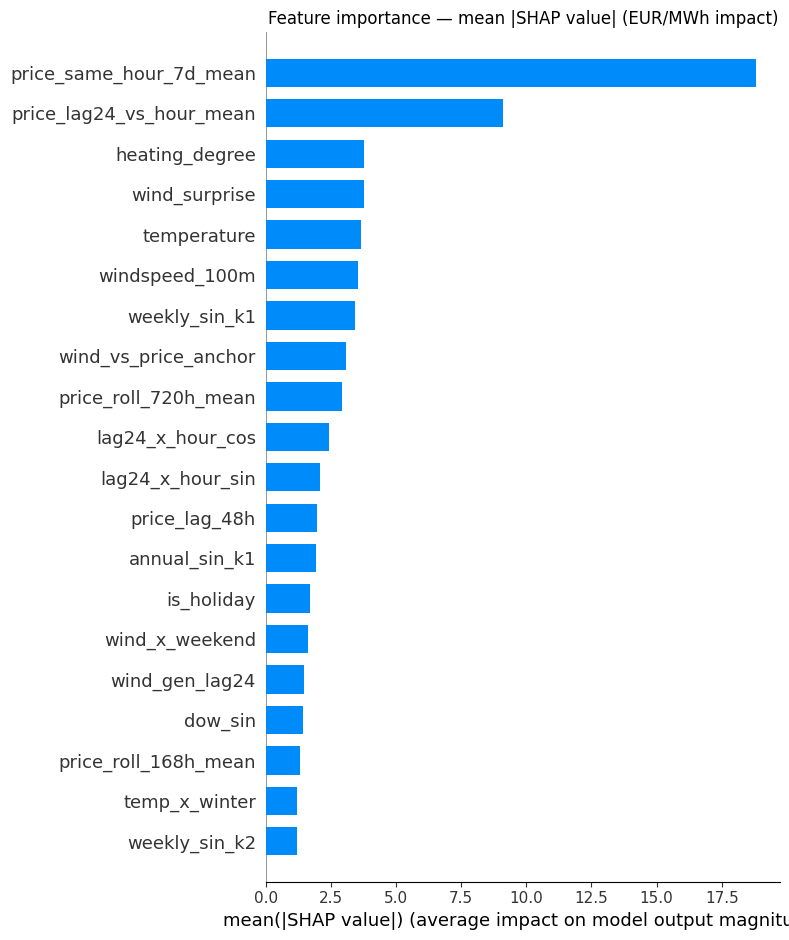

In [27]:
import shap
import matplotlib.pyplot as plt

# Use a sample of 500 rows to keep it fast
sample = X_test.sample(500, random_state=42)

explainer   = shap.TreeExplainer(model_p50)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
plt.title("Feature importance — mean |SHAP value| (EUR/MWh impact)")
plt.tight_layout()
plt.show()

## 12. Save the model
Save all three quantile models and the feature config.

In [28]:
import pickle, json, os

os.makedirs("model", exist_ok=True)

with open("model/model_p05.pkl", "wb") as f: pickle.dump(model_p05, f)
with open("model/model_p50.pkl", "wb") as f: pickle.dump(model_p50, f)
with open("model/model_p95.pkl", "wb") as f: pickle.dump(model_p95, f)

with open("model/feature_config.json", "w") as f:
    json.dump({"feature_cols": FEATURE_COLS, "target_col": TARGET_COL}, f, indent=2)

print("Saved to model/")
print("  model_p05.pkl  — lower bound (5th percentile)")
print("  model_p50.pkl  — median forecast")
print("  model_p95.pkl  — upper bound (95th percentile)")
print("  feature_config.json")

Saved to model/
  model_p05.pkl  — lower bound (5th percentile)
  model_p50.pkl  — median forecast
  model_p95.pkl  — upper bound (95th percentile)
  feature_config.json


## 13. Make a forecast for the next 24 hours

In [29]:
from data_cache import fetch_weather_forecast

# ── 1. Fetch 48h weather forecast ───────────────────────────────────────────
print("Fetching weather forecast...")
weather_fc = fetch_weather_forecast(WEATHER_LAT, WEATHER_LON)
print(f"  Weather forecast: {weather_fc.index.min()} → {weather_fc.index.max()}")

# ── 2. Future timestamps: next 24h after last known price ───────────────────
last_price_ts = prices.index.max()
future_ts = pd.date_range(
    start   = last_price_ts + pd.Timedelta(hours=1),
    periods = 24,
    freq    = "h",
    tz      = "Europe/Stockholm",
)
print(f"  Forecasting: {future_ts[0]} → {future_ts[-1]}")

# ── 3. Build feature matrix row-by-row ─────────────────────────────────────
price_s = prices["price_eur_mwh"]
wind_s  = weather["windspeed_100m"] if "windspeed_100m" in weather.columns else weather["windspeed_10m"]

def _get(series, ts):
    try:    return float(series.loc[ts])
    except: return float(series.iloc[series.index.get_indexer([ts], method="nearest")[0]])

def _get_gen(col, ts):
    if gen is None or col not in gen.columns: return np.nan
    try:    return float(gen.loc[ts, col])
    except: return float(gen[col].iloc[gen.index.get_indexer([ts], method="nearest")[0]])

rows = []
for ts in future_ts:
    r = {}

    # Calendar
    r["hour"]      = ts.hour
    r["dayofweek"] = ts.dayofweek
    r["month"]     = ts.month
    r["hour_sin"]  = np.sin(2*np.pi*ts.hour/24)
    r["hour_cos"]  = np.cos(2*np.pi*ts.hour/24)
    r["month_sin"] = np.sin(2*np.pi*ts.month/12)
    r["month_cos"] = np.cos(2*np.pi*ts.month/12)
    r["dow_sin"]   = np.sin(2*np.pi*ts.dayofweek/7)
    r["dow_cos"]   = np.cos(2*np.pi*ts.dayofweek/7)
    r["season"]    = {12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4}[ts.month]
    r["is_weekend"]= int(ts.dayofweek >= 5)
    r["is_holiday"]= int(ts.normalize() in se_holidays)
    r["is_peak"]   = int(ts.hour in list(range(7,10))+list(range(17,21)))
    r["is_night"]  = int(ts.hour in [23,0,1,2,3,4,5])

    # Fourier harmonics — deterministic from timestamp
    _how = ts.dayofweek * 24 + ts.hour
    _hoy = (ts.timetuple().tm_yday - 1) * 24 + ts.hour
    for k in [1, 2, 3]:
        r[f"daily_sin_k{k}"]  = np.sin(2*np.pi*k*ts.hour / 24)
        r[f"daily_cos_k{k}"]  = np.cos(2*np.pi*k*ts.hour / 24)
        r[f"weekly_sin_k{k}"] = np.sin(2*np.pi*k*_how    / 168)
        r[f"weekly_cos_k{k}"] = np.cos(2*np.pi*k*_how    / 168)
    for k in [1, 2]:
        r[f"annual_sin_k{k}"] = np.sin(2*np.pi*k*_hoy    / 8760)
        r[f"annual_cos_k{k}"] = np.cos(2*np.pi*k*_hoy    / 8760)

    # Price lags — all from known history
    lags = {h: _get(price_s, ts - pd.Timedelta(hours=h)) for h in [24,48,72,96,120,144,168]}
    r["price_lag_24h"]            = lags[24]
    r["price_lag_48h"]            = lags[48]
    r["price_lag_168h"]           = lags[168]
    r["price_same_hour_7d_mean"]  = np.nanmean(list(lags.values()))
    r["price_same_hour_3d_mean"]  = np.nanmean([lags[24],lags[48],lags[72]])
    r["price_lag24_vs_hour_mean"] = lags[24] - r["price_same_hour_7d_mean"]
    r["price_lag24_vs_3d_mean"]   = lags[24] - r["price_same_hour_3d_mean"]
    r["lag24_x_hour_sin"]         = lags[24] * r["hour_sin"]
    r["lag24_x_hour_cos"]         = lags[24] * r["hour_cos"]

    # Rolling price stats
    h168 = price_s[price_s.index < ts].tail(168)
    h720 = price_s[price_s.index < ts].tail(720)
    r["price_roll_168h_mean"] = float(h168.mean())
    r["price_roll_168h_std"]  = float(h168.std())
    r["price_roll_720h_mean"] = float(h720.mean())
    r["regime_x_vol"]         = r["price_roll_720h_mean"] * r["price_roll_168h_std"]

    # Weather from FORECAST API
    wfc = weather_fc.iloc[weather_fc.index.get_indexer([ts], method="nearest")[0]]
    r["temperature"]     = float(wfc["temperature"])
    r["windspeed_10m"]   = float(wfc["windspeed_10m"])
    r["windspeed_100m"]  = float(wfc["windspeed_100m"])
    r["solar_radiation"] = float(wfc["solar_radiation"])
    r["cloudcover"]      = float(wfc["cloudcover"])

    w = r["windspeed_100m"]
    r["heating_degree"]  = max(0, 15 - r["temperature"])
    r["wind_squared"]    = w**2
    r["wind_x_night"]    = w * r["is_night"]
    r["wind_x_peak"]     = w * r["is_peak"]
    r["wind_x_weekend"]  = w * r["is_weekend"]
    r["wind_x_winter"]   = w * int(r["season"]==1)
    r["wind_x_summer"]   = w * int(r["season"]==3)
    r["temp_x_night"]    = r["temperature"] * r["is_night"]
    r["temp_x_peak"]     = r["temperature"] * r["is_peak"]
    r["temp_x_winter"]   = r["temperature"] * int(r["season"]==1)
    r["cloud_x_solar"]   = r["cloudcover"] * r["solar_radiation"]

    # Wind surprise: forecast wind vs historical same-hour 7d mean
    wind_hist = [_get(wind_s, ts - pd.Timedelta(hours=h)) for h in [24,48,72,96,120,144,168]]
    r["wind_7d_mean"]          = np.nanmean(wind_hist)
    r["wind_surprise"]         = w - r["wind_7d_mean"]
    r["wind_surprise_x_night"] = r["wind_surprise"] * r["is_night"]
    r["wind_vs_price_anchor"]  = r["wind_surprise"] * r["price_same_hour_7d_mean"]

    # Generation lags from known history (24h back)
    lag_ts = ts - pd.Timedelta(hours=24)
    wg = _get_gen("wind_gen_mw", lag_ts)
    ld = _get_gen("load_mw",     lag_ts)
    r["wind_gen_lag24"]     = wg
    r["load_lag24"]         = ld
    r["wind_load_ratio"]    = wg/(ld+1)  if not np.isnan(wg) else np.nan
    r["wind_gen_x_night"]   = wg * r["is_night"]   if not np.isnan(wg) else np.nan
    r["wind_gen_x_weekend"] = wg * r["is_weekend"] if not np.isnan(wg) else np.nan
    r["load_residual"]      = max(0,ld-wg) if not (np.isnan(ld) or np.isnan(wg)) else np.nan

    rows.append(r)

fc_df = pd.DataFrame(rows, index=future_ts)
fc_cols = [c for c in FEATURE_COLS if c in fc_df.columns]
missing = [c for c in FEATURE_COLS if c not in fc_df.columns]
if missing: print(f"  Missing from forecast input: {missing}")

forecast = pd.DataFrame({
    "forecast_p05": model_p05.predict(fc_df[fc_cols]),
    "forecast_p50": model_p50.predict(fc_df[fc_cols]),
    "forecast_p95": model_p95.predict(fc_df[fc_cols]),
}, index=future_ts)

print("\nNext 24h SE3 price forecast (EUR/MWh):")
print(forecast.round(1).to_string())

# ── Plot ─────────────────────────────────────────────────────────────────────
import plotly.graph_objects as go

actuals        = df["price_eur_mwh"].tail(48)
forecast_start = future_ts[0].strftime("%Y-%m-%d %H:%M:%S")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(forecast.index)+list(forecast.index[::-1]),
    y=list(forecast["forecast_p95"])+list(forecast["forecast_p05"][::-1]),
    fill="toself", fillcolor="rgba(99,153,255,0.15)",
    line=dict(color="rgba(0,0,0,0)"), name="90% confidence band (q5–q95)",
))
fig.add_trace(go.Scatter(
    x=forecast.index, y=forecast["forecast_p50"],
    name="Forecast (median)", line=dict(color="#2563eb", width=2.5),
))
fig.add_trace(go.Scatter(
    x=actuals.index, y=actuals.values,
    name="Actual (last 48h)", line=dict(color="#333", width=1.5, dash="dot"),
))
fig.add_shape(
    type="line", x0=forecast_start, x1=forecast_start,
    y0=0, y1=1, xref="x", yref="paper",
    line=dict(color="gray", width=1, dash="dash"),
)
fig.add_annotation(
    x=forecast_start, y=1, xref="x", yref="paper",
    text="Forecast start", showarrow=False,
    xanchor="left", font=dict(color="gray", size=11),
)
fig.update_layout(
    title=f"SE3 Next 24h Forecast — generated {pd.Timestamp.now('Europe/Stockholm').strftime('%Y-%m-%d %H:%M')}",
    xaxis_title="Time", yaxis_title="EUR/MWh",
    yaxis=dict(rangemode="tozero"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    hovermode="x unified", template="plotly_white", height=420,
)
fig.show()

Fetching weather forecast...
  Weather forecast: 2026-04-24 00:00:00+02:00 → 2026-04-25 23:00:00+02:00
  Forecasting: 2026-03-31 01:00:00+02:00 → 2026-04-01 00:00:00+02:00

Next 24h SE3 price forecast (EUR/MWh):
                           forecast_p05  forecast_p50  forecast_p95
2026-03-31 01:00:00+02:00          13.4          33.4          63.4
2026-03-31 02:00:00+02:00          11.2          30.8          57.7
2026-03-31 03:00:00+02:00           9.6          30.2          52.9
2026-03-31 04:00:00+02:00           9.1          30.2          52.9
2026-03-31 05:00:00+02:00          10.2          31.0          57.8
2026-03-31 06:00:00+02:00          11.9          30.5          66.9
2026-03-31 07:00:00+02:00          26.0          49.7          90.1
2026-03-31 08:00:00+02:00          31.0          57.5          96.5
2026-03-31 09:00:00+02:00          34.2          58.6         102.5
2026-03-31 10:00:00+02:00          30.7          56.3          88.7
2026-03-31 11:00:00+02:00          28.1 

---
## Next steps
- ✅ Removed data leakage (price_lag_1h)
- ✅ Removed over-dominant price_roll_24h_mean
- ✅ Added generation features (wind, load)
- ✅ Fixed DST timezone handling throughout
- ✅ Fixed deprecated sklearn squared=False
- ✅ Fixed 24h forecast double-shifting bug
- ✅ Added cyclical calendar encodings (hour_sin/cos, month_sin/cos, dow_sin/cos)
- ✅ Added wind × time-of-day interaction features
- ✅ Added temperature × season interactions
- ✅ Added lag × hour interactions (fixes midnight forecast gap)
- ✅ Added regime × volatility feature (fixes 2022 vs 2024 over-forecast)
- ✅ Early stopping — faster training, better generalisation
- Tune hyperparameters with Optuna
- Package into a GCP Cloud Function for daily retraining
- Build the Streamlit dashboard